# Examples for OptPulseProcessor

Author: Boxi Li (etamin1201@gmail.com)

In [1]:
from numpy import pi
from qutip import basis, fidelity, identity, sigmax, sigmaz, tensor
from qutip_qip.circuit import QubitCircuit
from qutip_qip.device import OptPulseProcessor
from qutip_qip.operations import expand_operator, toffoli
from qutip.ipynbtools import version_table
import qutip_qip

The `qutip.OptPulseProcessor` is a noisy quantum device simulator integrated with the optimal pulse algorithm from the `qutip.control` module. It is a subclass of `qutip.Processor` and is equipped with a method to find the optimal pulse sequence (hence the name `OptPulseProcessor`) for a `qutip.QubitCircuit` or a list of `qutip.Qobj`. For the user guide of `qutip.Processor`, please refer to [the introductory guide](https://qutip-qip.readthedocs.io/en/stable/qip-processor.html).

## Single-qubit gate
Like in the parent class `Processor`, we need to first define the available Hamiltonians in the system. The `OptPulseProcessor` has one more parameter, the drift Hamiltonian, which has no time-dependent coefficients and thus won't be optimized.

In [2]:
num_qubits = 1
# Drift Hamiltonian
H_d = sigmaz()
# The (single) control Hamiltonian
H_c = sigmax()
processor = OptPulseProcessor(num_qubits, drift=H_d)
processor.add_control(H_c, 0)

The method `load_circuit` calls `qutip.control.optimize_pulse_unitary` and returns the pulse coefficients.

********** Gate 0 **********
Final fidelity error 1.4523937608146298e-12
Final gradient normal 3.1519151453131223e-06
Terminated due to Goal achieved
Number of iterations 11


/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


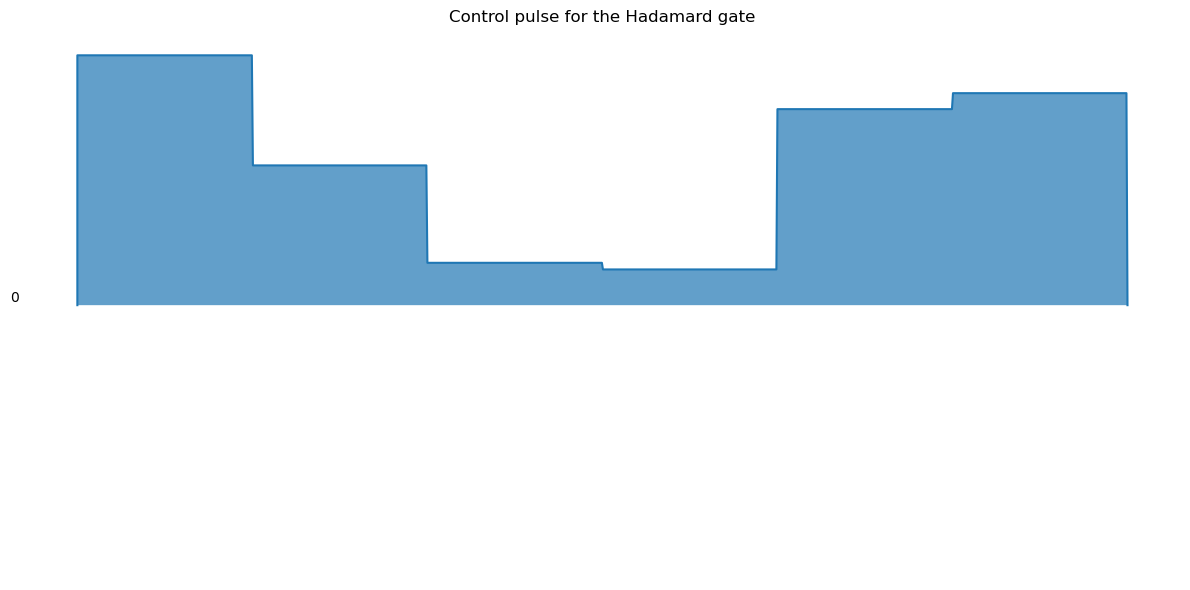

In [3]:
qc = QubitCircuit(num_qubits)
qc.add_gate("SNOT", 0)

# This method calls optimize_pulse_unitary
tlist, coeffs = processor.load_circuit(
    qc, min_grad=1e-20, init_pulse_type="RND", num_tslots=6,
    evo_time=1, verbose=True
)
processor.plot_pulses(
    title="Control pulse for the Hadamard gate", use_control_latex=False
);

Like the `Processor`, the simulation is calculated with a QuTiP solver. The method `run_state` calls `mesolve` and returns the result. One can also add noise to observe the change in the fidelity, e.g. the t1 decoherence time.

In [4]:
rho0 = basis(2, 1)
plus = (basis(2, 0) + basis(2, 1)).unit()
minus = (basis(2, 0) - basis(2, 1)).unit()
result = processor.run_state(init_state=rho0)
print("Fidelity:", fidelity(result.states[-1], minus))

# add noise
processor.t1 = 40.0
result = processor.run_state(init_state=rho0)
print("Fidelity with qubit relaxation:", fidelity(result.states[-1], minus))

Fidelity: 0.9999999997377431
Fidelity with qubit relaxation: 0.9934150715263628


## Multi-qubit gate

In the following example, we use `OptPulseProcessor` to find the optimal control pulse of a multi-qubit circuit. For simplicity, the circuit contains only one Toffoli gate.

In [5]:
toffoli()

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]]

We have single-qubit control $\sigma_x$ and $\sigma_z$, with the argument `cyclic_permutation=True`, it creates 3 operators each targeted on one qubit.

In [6]:
N = 3
H_d = tensor([identity(2)] * 3)
test_processor = OptPulseProcessor(N, H_d)
test_processor.add_control(sigmaz(), cyclic_permutation=True)
test_processor.add_control(sigmax(), cyclic_permutation=True)

The interaction is generated by $\sigma_x\sigma_x$ between the qubit 0 & 1 and qubit 1 & 2. `expand_operator` can be used to expand the operator to a larger dimension with given target qubits.

In [7]:
sxsx = tensor([sigmax(), sigmax()])
sxsx01 = expand_operator(sxsx, 3, targets=[0, 1])
sxsx12 = expand_operator(sxsx, 3, targets=[1, 2])
test_processor.add_control(sxsx01)
test_processor.add_control(sxsx12)

/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/qutip_qip/operations/gates.py:1284: DeprecationWarning: The function expand_operator has been generalized to arbitrary subsystems instead of only qubit systems.Please use the new signature e.g.
expand_operator(oper, dims=[2, 3, 2, 2], targets=2)
  warnings.warn(
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/qutip_qip/operations/gates.py:1284: DeprecationWarning: The function expand_operator has been generalized to arbitrary subsystems instead of only qubit systems.Please use the new signature e.g.
expand_operator(oper, dims=[2, 3, 2, 2], targets=2)
  warnings.warn(


Use the above defined control Hamiltonians, we now find the optimal pulse for the Toffoli gate with 6 time slots. Instead of a `QubitCircuit`, a list of operators can also be given as an input.

In [8]:
def get_control_latex():
    """
    Get the labels for each Hamiltonian.
    It is used in the method``plot_pulses``.
    It is a 2-d nested list, in the plot,
    a different color will be used for each sublist.
    """
    return [
        [r"$\sigma_z^%d$" % n for n in range(test_processor.num_qubits)],
        [r"$\sigma_x^%d$" % n for n in range(test_processor.num_qubits)],
        [r"$g_01$", r"$g_12$"],
    ]


test_processor.model.get_control_latex = get_control_latex

In [9]:
test_processor.dims = [2, 2, 2]

********** Gate 0 **********
Final fidelity error 3.059755115941698e-09
Final gradient normal 6.1132522838973435e-06
Terminated due to function converged
Number of iterations 218


/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/fontconfig_pattern.py:127: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  self._parser.parseString(pattern)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/fontconfig_pattern.py:134: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._parser.resetCache()
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/fontconfig_pattern.py:127: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  self._parser.parseString(pattern)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/fontconfig_pattern.py:134: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._parser.resetCache()
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/fontconfig_pattern.py:1

/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2245: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._expression.resetCache()


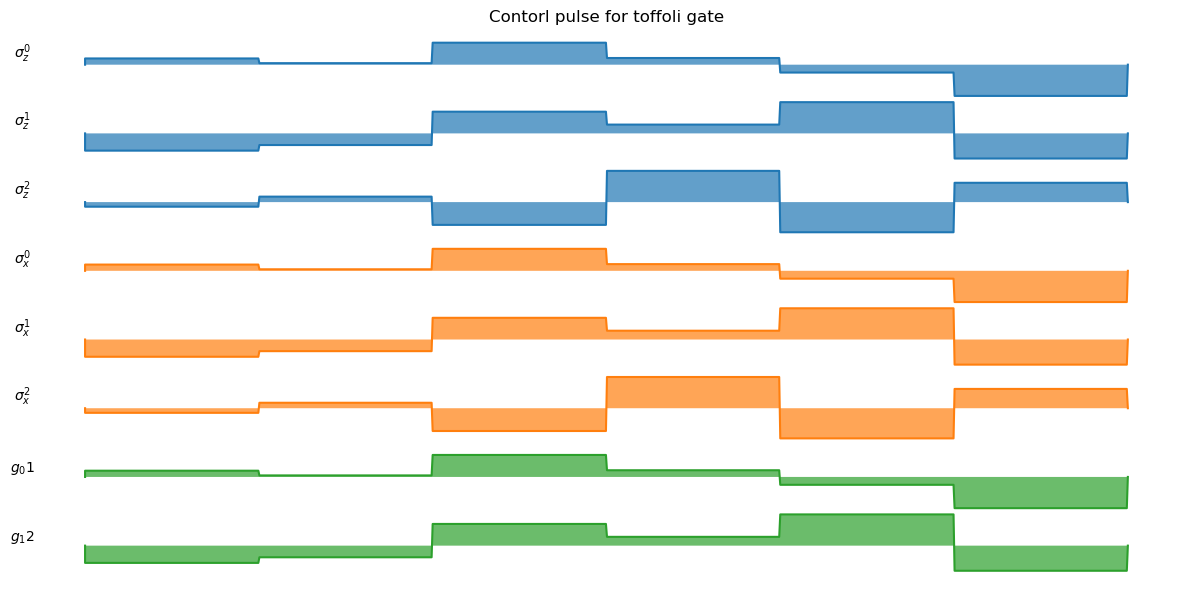

In [10]:
test_processor.load_circuit([toffoli()], num_tslots=6,
                            evo_time=1, verbose=True)

test_processor.plot_pulses(title="Contorl pulse for toffoli gate");

## Merging a quantum circuit
If there are multiple gates in the circuit, we can choose if we want to first merge them and then find the pulse for the merged unitary.

In [11]:
qc = QubitCircuit(3)
qc.add_gate("CNOT", controls=0, targets=2)
qc.add_gate("RX", targets=2, arg_value=pi / 4)
qc.add_gate("RY", targets=1, arg_value=pi / 8)

********** Gate 0 **********
Final fidelity error 0.292892458934204
Final gradient normal 4.9039226589760494e-05
Terminated due to function converged
Number of iterations 191
********** Gate 1 **********
Final fidelity error 3.708011675485068e-11
Final gradient normal 8.915137208497646e-05
Terminated due to Goal achieved
Number of iterations 8
********** Gate 2 **********
Final fidelity error 1.8637753118611045e-08
Final gradient normal 2.9535613544737162e-05
Terminated due to function converged
Number of iterations 25


/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2300: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1])
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2245: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._expression.resetCache()
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_math

/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2300: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1])
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2245: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._expression.resetCache()
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_math

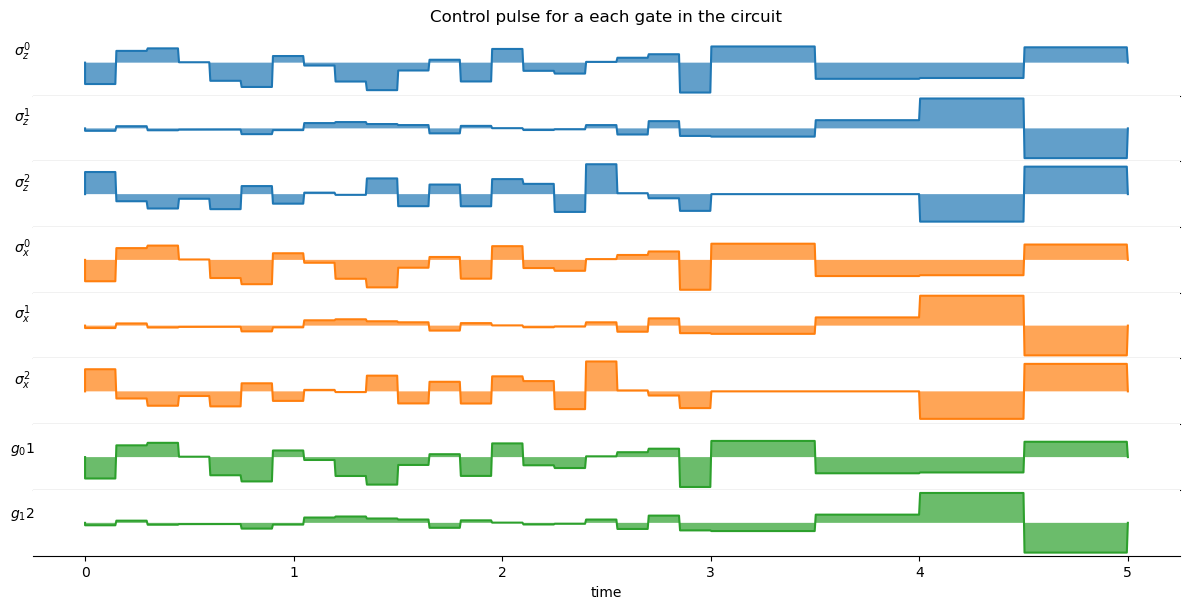

In [12]:
setting_args = {
    "CNOT": {"num_tslots": 20, "evo_time": 3},
    "RX": {"num_tslots": 2, "evo_time": 1},
    "RY": {"num_tslots": 2, "evo_time": 1},
}

test_processor.load_circuit(
    qc, merge_gates=False, setting_args=setting_args, verbose=True
)
fig, axes = test_processor.plot_pulses(
    title="Control pulse for a each gate in the circuit", show_axis=True
)
axes[-1].set_xlabel("time");

In the above figure, the pulses from $t=0$ to $t=3$ are for the CNOT gate while the rest for are the two single qubits gates. The difference in the frequency of change is merely a result of our choice of `evo_time`. Here we can see that the three gates are carried out in sequence.

********** Gate 0 **********
Final fidelity error 6.574967031935941e-07
Final gradient normal 5.610008997225508e-05
Terminated due to function converged
Number of iterations 234


/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2300: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1])
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2245: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  self._expression.resetCache()
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_mathtext.py:2237: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/home/runner/miniconda3/envs/test-environment-v4/lib/python3.10/site-packages/matplotlib/_math

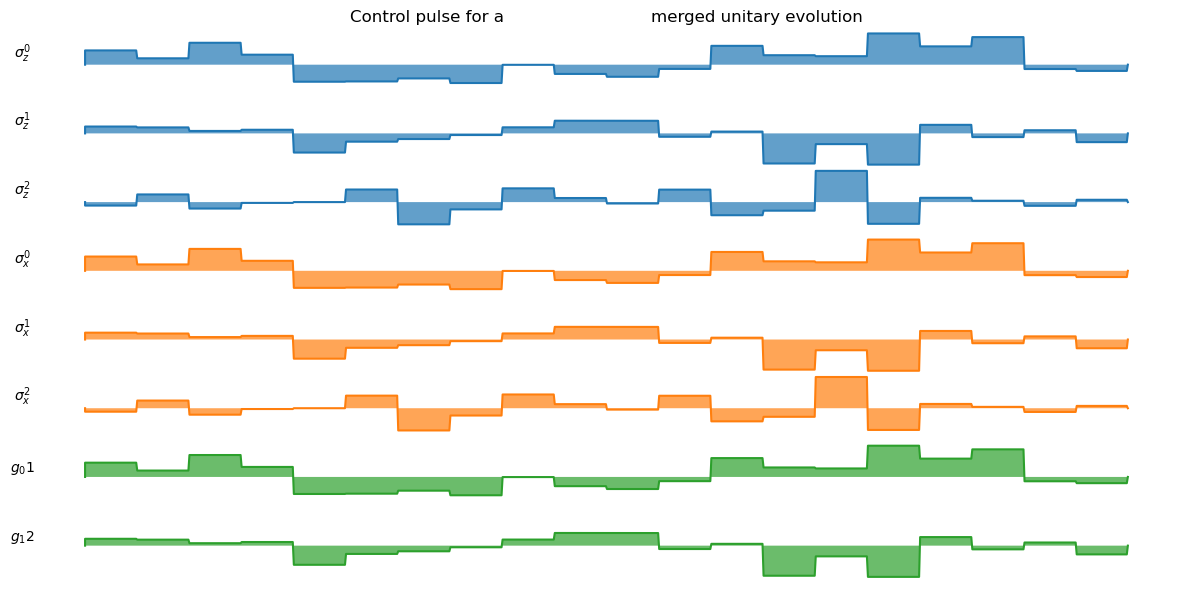

In [13]:
qc = QubitCircuit(3)
qc.add_gate("CNOT", controls=0, targets=2)
qc.add_gate("RX", targets=2, arg_value=pi / 4)
qc.add_gate("RY", targets=1, arg_value=pi / 8)
test_processor.load_circuit(
    qc, merge_gates=True, verbose=True, num_tslots=20, evo_time=5
)
test_processor.plot_pulses(title="Control pulse for a \
                           merged unitary evolution");

In this figure there are no different stages, the three gates are first merged and then the algorithm finds the optimal pulse for the resulting unitary evolution.

In [14]:
print("qutip-qip version:", qutip_qip.version.version)
version_table()

qutip-qip version: 0.4.2


Software,Version
QuTiP,4.7.6
Numpy,1.26.4
SciPy,1.12.0
matplotlib,3.5.2
Cython,0.29.37
Number of CPUs,4
BLAS Info,Generic
IPython,8.37.0
Python,"3.10.4 | packaged by conda-forge | (main, Mar 24 2022, 17:39:04) [GCC 10.3.0]"
OS,posix [linux]
